In [4]:
import os, warnings
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
warnings.filterwarnings("ignore")

# Auto-detect root whether running from notebooks/ or project root
CWD = os.getcwd()
ROOT = os.path.dirname(CWD) if os.path.basename(CWD).lower() in ("notebooks","notebook") else CWD
RAW_DIR  = os.path.join(ROOT, "data", "raw")
PROC_DIR = os.path.join(ROOT, "data", "processed")
os.makedirs(PROC_DIR, exist_ok=True)

RF = 0.065   # RBI repo rate proxy
TD = 252     # trading days per year

def _need(fname):
    p = os.path.join(PROC_DIR, fname)
    return not os.path.exists(p) or os.path.getsize(p) == 0

# ── Generate processed files if missing ──────────────────────────────────────
if _need("clean_fund_master.csv"):
    fm = pd.read_csv(os.path.join(RAW_DIR, "01_fund_master.csv"))
    fm["launch_date"] = pd.to_datetime(fm["launch_date"], errors="coerce")
    fm["amfi_code"]   = fm["amfi_code"].astype(str)
    fm.to_csv(os.path.join(PROC_DIR, "clean_fund_master.csv"), index=False)
    print("Generated clean_fund_master.csv")

if _need("clean_nav.csv"):
    print("Generating clean_nav.csv ...")
    nav_raw = pd.read_csv(os.path.join(RAW_DIR, "02_nav_history.csv"))
    nav_raw["date"]      = pd.to_datetime(nav_raw["date"], errors="coerce")
    nav_raw["amfi_code"] = nav_raw["amfi_code"].astype(str)
    nav_raw = nav_raw.sort_values(["amfi_code","date"]).drop_duplicates(subset=["amfi_code","date"])
    nav_raw = nav_raw[nav_raw["nav"] > 0].copy()
    filled = []
    for code, g in nav_raw.groupby("amfi_code"):
        g = g.set_index("date")
        g = g.reindex(pd.bdate_range(g.index.min(), g.index.max())).ffill()
        g = g.reset_index().rename(columns={"index":"date"})
        g["amfi_code"] = code
        filled.append(g[["amfi_code","date","nav"]])
    pd.concat(filled, ignore_index=True).dropna().to_csv(
        os.path.join(PROC_DIR, "clean_nav.csv"), index=False)
    print("Generated clean_nav.csv")

if _need("clean_benchmark_indices.csv"):
    bench_raw = pd.read_csv(os.path.join(RAW_DIR, "10_benchmark_indices.csv"))
    bench_raw["date"] = pd.to_datetime(bench_raw["date"], errors="coerce")
    bench_raw.sort_values(["index_name","date"]).drop_duplicates().to_csv(
        os.path.join(PROC_DIR, "clean_benchmark_indices.csv"), index=False)
    print("Generated clean_benchmark_indices.csv")

if _need("clean_performance.csv"):
    print("Generating clean_performance.csv ...")
    nav_tmp = pd.read_csv(os.path.join(PROC_DIR, "clean_nav.csv"), parse_dates=["date"])
    def _cagr(g, years):
        sub = g[g["date"] >= g["date"].iloc[-1] - pd.DateOffset(years=years)]
        if len(sub) < 20: return np.nan
        return (g["nav"].iloc[-1] / sub["nav"].iloc[0]) ** (TD/len(sub)) - 1
    rows = []
    for code, g in nav_tmp.groupby("amfi_code"):
        g = g.sort_values("date").reset_index(drop=True)
        daily    = g["nav"].pct_change().dropna()
        ann_ret  = (1+daily).prod()**(TD/len(daily)) - 1
        ann_std  = daily.std() * np.sqrt(TD)
        down_std = daily[daily<0].std() * np.sqrt(TD)
        max_dd   = ((g["nav"] - g["nav"].cummax()) / g["nav"].cummax()).min()
        r1,r3,r5 = _cagr(g,1), _cagr(g,3), _cagr(g,5)
        rows.append({
            "amfi_code":        str(code),
            "as_of_date":       str(g["date"].iloc[-1].date()),
            "return_1yr_pct":   round(r1*100,4) if not np.isnan(r1) else np.nan,
            "return_3yr_pct":   round(r3*100,4) if not np.isnan(r3) else np.nan,
            "return_5yr_pct":   round(r5*100,4) if not np.isnan(r5) else np.nan,
            "benchmark_3yr_pct":np.nan,
            "alpha":            np.nan,
            "beta":             np.nan,
            "sharpe_ratio":     round((ann_ret-RF)/ann_std,  4) if ann_std  > 0 else np.nan,
            "sortino_ratio":    round((ann_ret-RF)/down_std, 4) if down_std > 0 else np.nan,
            "std_dev_ann_pct":  round(ann_std*100, 4),
            "max_drawdown_pct": round(max_dd*100,  4),
        })
    pd.DataFrame(rows).to_csv(os.path.join(PROC_DIR, "clean_performance.csv"), index=False)
    print("Generated clean_performance.csv")

# ── Load ─────────────────────────────────────────────────────────────────────
nav   = pd.read_csv(os.path.join(PROC_DIR, "clean_nav.csv"),               parse_dates=["date"])
fm    = pd.read_csv(os.path.join(PROC_DIR, "clean_fund_master.csv"))
perf  = pd.read_csv(os.path.join(PROC_DIR, "clean_performance.csv"))
bench = pd.read_csv(os.path.join(PROC_DIR, "clean_benchmark_indices.csv"), parse_dates=["date"])

nav["amfi_code"]  = nav["amfi_code"].astype(str)
fm["amfi_code"]   = fm["amfi_code"].astype(str)
perf["amfi_code"] = perf["amfi_code"].astype(str)
asof = nav["date"].max()

print(f"\n✅ Data loaded. As-of date: {asof.date()}")
print(f"   nav {nav.shape} | fm {fm.shape} | perf {perf.shape} | bench {bench.shape}")


✅ Data loaded. As-of date: 2026-05-29
   nav (46000, 4) | fm (40, 15) | perf (40, 21) | bench (8050, 3)


In [5]:
# Task 1: Compute daily returns for all funds
nav = nav.sort_values(["amfi_code","date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print("Daily returns sample:")
print(nav[nav["amfi_code"]=="119551"][["date","nav","daily_return"]].tail(5).to_string(index=False))
print(f"\nReturn stats across all funds:")
print(nav["daily_return"].describe().round(6))

Daily returns sample:
      date      nav  daily_return
2026-05-25 151.3832      0.000654
2026-05-26 150.0040     -0.009111
2026-05-27 148.1874     -0.012110
2026-05-28 150.3635      0.014685
2026-05-29 149.3216     -0.006929

Return stats across all funds:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [6]:
# Task 2: CAGR per fund per horizon
def compute_cagr(group, years):
    group = group.sort_values("date")
    end_date   = group["date"].iloc[-1]
    start_date = end_date - pd.DateOffset(years=years)
    sub = group[group["date"] >= start_date]
    if len(sub) < 20:
        return np.nan
    n_years = len(sub) / TD
    return (group["nav"].iloc[-1] / sub["nav"].iloc[0]) ** (1 / n_years) - 1

cagr_rows = []
for code, g in nav.groupby("amfi_code"):
    name = fm.loc[fm["amfi_code"]==code, "scheme_name"].values
    name = name[0][:40] if len(name) else code
    cagr_rows.append({
        "amfi_code":   code,
        "scheme_name": name,
        "CAGR_1yr":    round(compute_cagr(g, 1)*100, 2),
        "CAGR_3yr":    round(compute_cagr(g, 3)*100, 2),
        "CAGR_5yr":    round(compute_cagr(g, 5)*100, 2),
    })

cagr_df = pd.DataFrame(cagr_rows).dropna(subset=["CAGR_3yr"]).sort_values("CAGR_3yr", ascending=False)
cagr_df.to_csv(os.path.join(PROC_DIR, "cagr_report.csv"), index=False)

print("Top 10 funds by 3yr CAGR:")
print(cagr_df[["scheme_name","CAGR_1yr","CAGR_3yr","CAGR_5yr"]].head(10).to_string(index=False))

Top 10 funds by 3yr CAGR:
                             scheme_name  CAGR_1yr  CAGR_3yr  CAGR_5yr
     Axis Midcap Fund - Regular - Growth     21.33     33.62     27.08
Mirae Asset Large Cap Fund - Regular - G     19.51     32.56     29.71
ICICI Pru Bluechip Fund - Direct - Growt     12.54     31.12     22.37
HDFC Mid-Cap Opportunities Fund - Regula     50.76     31.07     28.90
ICICI Pru Midcap Fund - Regular - Growth     28.33     30.44     31.48
SBI Bluechip Fund - Regular Plan - Growt     57.57     29.18     24.77
  Kotak Flexicap Fund - Regular - Growth     25.52     28.35     29.65
Mirae Asset Tax Saver Fund - Regular - G     37.98     27.96     30.64
ABSL Frontline Equity Fund - Regular - G     45.73     27.76     22.60
   DSP Small Cap Fund - Regular - Growth     62.01     25.88     30.97


In [7]:
# Task 3: Sharpe Ratio
sharpe_rows = []
for code, g in nav.groupby("amfi_code"):
    daily  = g["daily_return"].dropna()
    ann_ret = (1 + daily).prod() ** (TD / len(daily)) - 1
    ann_std = daily.std() * np.sqrt(TD)
    sharpe  = (ann_ret - RF) / ann_std if ann_std > 0 else np.nan
    name    = fm.loc[fm["amfi_code"]==code, "scheme_name"].values
    sharpe_rows.append({
        "amfi_code":   code,
        "scheme_name": name[0][:40] if len(name) else code,
        "ann_return":  round(ann_ret * 100, 2),
        "ann_std":     round(ann_std * 100, 2),
        "sharpe_ratio":round(sharpe,  4),
    })

sharpe_df = pd.DataFrame(sharpe_rows).sort_values("sharpe_ratio", ascending=False)
sharpe_df.to_csv(os.path.join(PROC_DIR, "sharpe_values.csv"), index=False)

print("Top 10 by Sharpe Ratio:")
print(sharpe_df[["scheme_name","ann_return","ann_std","sharpe_ratio"]].head(10).to_string(index=False))

Top 10 by Sharpe Ratio:
                             scheme_name  ann_return  ann_std  sharpe_ratio
Mirae Asset Large Cap Fund - Regular - G       29.74    14.19        1.6374
  Kotak Flexicap Fund - Regular - Growth       29.68    15.89        1.4589
Mirae Asset Tax Saver Fund - Regular - G       30.67    17.67        1.3677
SBI Bluechip Fund - Regular Plan - Growt       24.80    13.74        1.3315
ICICI Pru Midcap Fund - Regular - Growth       31.51    19.29        1.2966
      DSP Midcap Fund - Regular - Growth       28.41    17.75        1.2346
HDFC Mid-Cap Opportunities Fund - Regula       28.93    18.94        1.1844
Nippon India Large Cap Fund - Regular -        23.12    14.15        1.1744
ABSL Frontline Equity Fund - Regular - G       22.63    14.57        1.1070
ICICI Pru Bluechip Fund - Direct - Growt       22.39    14.36        1.1065


In [8]:
# Task 4: Sortino Ratio
sortino_rows = []
for code, g in nav.groupby("amfi_code"):
    daily     = g["daily_return"].dropna()
    ann_ret   = (1 + daily).prod() ** (TD / len(daily)) - 1
    down_std  = daily[daily < 0].std() * np.sqrt(TD)
    sortino   = (ann_ret - RF) / down_std if down_std > 0 else np.nan
    name      = fm.loc[fm["amfi_code"]==code, "scheme_name"].values
    sortino_rows.append({
        "amfi_code":    code,
        "scheme_name":  name[0][:40] if len(name) else code,
        "ann_return":   round(ann_ret * 100, 2),
        "downside_std": round(down_std * 100, 2),
        "sortino_ratio":round(sortino, 4),
    })

sortino_df = pd.DataFrame(sortino_rows).sort_values("sortino_ratio", ascending=False)
sortino_df.to_csv(os.path.join(PROC_DIR, "sortino_values.csv"), index=False)

print("Top 10 by Sortino Ratio:")
print(sortino_df[["scheme_name","ann_return","downside_std","sortino_ratio"]].head(10).to_string(index=False))

Top 10 by Sortino Ratio:
                             scheme_name  ann_return  downside_std  sortino_ratio
Mirae Asset Large Cap Fund - Regular - G       29.74          8.62         2.6972
  Kotak Flexicap Fund - Regular - Growth       29.68          8.78         2.6396
Mirae Asset Tax Saver Fund - Regular - G       30.67         10.17         2.3778
SBI Bluechip Fund - Regular Plan - Growt       24.80          7.76         2.3585
ICICI Pru Midcap Fund - Regular - Growth       31.51         11.22         2.2297
      DSP Midcap Fund - Regular - Growth       28.41         10.71         2.0448
ICICI Pru Liquid Fund - Regular - Growth        6.98          0.23         2.0422
Nippon India Large Cap Fund - Regular -        23.12          8.27         2.0088
HDFC Mid-Cap Opportunities Fund - Regula       28.93         11.32         1.9808
ICICI Pru Bluechip Fund - Direct - Growt       22.39          8.17         1.9459


In [9]:
# Task 5: Alpha & Beta via OLS regression against NIFTY100
nifty100 = (bench[bench["index_name"]=="NIFTY100"]
            .sort_values("date")
            .set_index("date")["close_value"]
            .pct_change()
            .rename("market_ret"))

ab_rows = []
for code, g in nav.groupby("amfi_code"):
    g = g.sort_values("date").set_index("date")
    merged = g["daily_return"].to_frame().join(nifty100, how="inner").dropna()
    if len(merged) < 60:
        continue
    slope, intercept, r, p, se = stats.linregress(merged["market_ret"], merged["daily_return"])
    beta  = round(slope, 4)
    alpha = round(intercept * TD * 100, 4)   # annualised alpha in %
    name  = fm.loc[fm["amfi_code"]==code, "scheme_name"].values
    ab_rows.append({
        "amfi_code":   code,
        "scheme_name": name[0][:40] if len(name) else code,
        "alpha_ann_pct": alpha,
        "beta":          beta,
        "r_squared":     round(r**2, 4),
    })

ab_df = pd.DataFrame(ab_rows).sort_values("alpha_ann_pct", ascending=False)
ab_df.to_csv(os.path.join(PROC_DIR, "alpha_beta.csv"), index=False)

# Merge alpha/beta back into perf
perf = perf.merge(ab_df[["amfi_code","alpha_ann_pct","beta"]], on="amfi_code", how="left")
perf["alpha"] = perf["alpha_ann_pct"]
perf.to_csv(os.path.join(PROC_DIR, "clean_performance.csv"), index=False)

print("Alpha & Beta (top 10 by Alpha):")
print(ab_df[["scheme_name","alpha_ann_pct","beta","r_squared"]].head(10).to_string(index=False))

Alpha & Beta (top 10 by Alpha):
                             scheme_name  alpha_ann_pct    beta  r_squared
SBI Small Cap Fund - Regular Plan - Grow        30.3370 -0.0232     0.0001
   DSP Small Cap Fund - Regular - Growth        30.0579  0.0115     0.0000
ICICI Pru Midcap Fund - Regular - Growth        29.2636  0.0005     0.0000
Mirae Asset Tax Saver Fund - Regular - G        28.2704  0.0181     0.0002
  Kotak Flexicap Fund - Regular - Growth        27.3305 -0.0228     0.0003
HDFC Mid-Cap Opportunities Fund - Regula        27.1954  0.0051     0.0000
Mirae Asset Large Cap Fund - Regular - G        26.9838  0.0237     0.0005
      DSP Midcap Fund - Regular - Growth        26.5986 -0.0025     0.0000
     Axis Midcap Fund - Regular - Growth        26.0767 -0.0663     0.0019
SBI Bluechip Fund - Regular Plan - Growt        23.2010 -0.0318     0.0009


In [10]:
# Task 6: Maximum Drawdown
dd_rows = []
for code, g in nav.groupby("amfi_code"):
    g = g.sort_values("date").copy()
    g["roll_max"] = g["nav"].cummax()
    g["drawdown"] = (g["nav"] - g["roll_max"]) / g["roll_max"]
    max_dd     = g["drawdown"].min()
    worst_date = g.loc[g["drawdown"].idxmin(), "date"]
    name       = fm.loc[fm["amfi_code"]==code, "scheme_name"].values
    dd_rows.append({
        "amfi_code":        code,
        "scheme_name":      name[0][:40] if len(name) else code,
        "max_drawdown_pct": round(max_dd * 100, 2),
        "worst_date":       str(worst_date.date()),
    })

dd_df = pd.DataFrame(dd_rows).sort_values("max_drawdown_pct")
dd_df.to_csv(os.path.join(PROC_DIR, "max_drawdown.csv"), index=False)

print("Worst 10 drawdowns:")
print(dd_df[["scheme_name","max_drawdown_pct","worst_date"]].head(10).to_string(index=False))


Worst 10 drawdowns:
                             scheme_name  max_drawdown_pct worst_date
SBI Small Cap Fund - Direct Plan - Growt            -52.57 2025-10-28
  Axis Small Cap Fund - Regular - Growth            -51.68 2026-05-11
  ABSL Small Cap Fund - Regular - Growth            -35.45 2026-05-11
   DSP Small Cap Fund - Regular - Growth            -31.17 2025-01-03
SBI Small Cap Fund - Regular Plan - Grow            -28.71 2025-05-14
     UTI Mid Cap Fund - Regular - Growth            -28.00 2026-04-27
HDFC Top 100 Fund - Regular Plan - Growt            -24.73 2022-09-15
Kotak Emerging Equity Fund - Regular - G            -24.00 2024-10-17
Nippon India Small Cap Fund - Regular -             -23.34 2026-02-20
    Axis Bluechip Fund - Direct - Growth            -21.75 2023-05-22


In [11]:
# Task 7: Composite Scorecard (0–100)
score_df = (cagr_df[["amfi_code","CAGR_3yr"]]
            .merge(sharpe_df[["amfi_code","sharpe_ratio"]], on="amfi_code")
            .merge(ab_df[["amfi_code","alpha_ann_pct"]], on="amfi_code")
            .merge(fm[["amfi_code","expense_ratio_pct"]], on="amfi_code")
            .merge(dd_df[["amfi_code","max_drawdown_pct"]], on="amfi_code")
            .merge(fm[["amfi_code","scheme_name"]], on="amfi_code"))

def rank_pct(series, ascending=True):
    """Rank series and return 0–100 percentile score."""
    return series.rank(ascending=ascending, pct=True) * 100

score_df["s_return"] = rank_pct(score_df["CAGR_3yr"],        ascending=True)
score_df["s_sharpe"] = rank_pct(score_df["sharpe_ratio"],    ascending=True)
score_df["s_alpha"]  = rank_pct(score_df["alpha_ann_pct"],   ascending=True)
score_df["s_er"]     = rank_pct(score_df["expense_ratio_pct"], ascending=False)  # lower is better
score_df["s_dd"]     = rank_pct(score_df["max_drawdown_pct"],  ascending=False)  # less negative is better

score_df["composite_score"] = (
    0.30 * score_df["s_return"] +
    0.25 * score_df["s_sharpe"] +
    0.20 * score_df["s_alpha"]  +
    0.15 * score_df["s_er"]     +
    0.10 * score_df["s_dd"]
).round(2)

score_df = score_df.sort_values("composite_score", ascending=False).reset_index(drop=True)
score_df["rank"] = score_df.index + 1
score_df.to_csv(os.path.join(PROC_DIR, "fund_scorecard.csv"), index=False)

cols = ["rank","scheme_name","composite_score","CAGR_3yr","sharpe_ratio","alpha_ann_pct","expense_ratio_pct","max_drawdown_pct"]
print("Fund Scorecard (Top 15):")
print(score_df[cols].head(15).to_string(index=False))

Fund Scorecard (Top 15):
 rank                                        scheme_name  composite_score  CAGR_3yr  sharpe_ratio  alpha_ann_pct  expense_ratio_pct  max_drawdown_pct
    1           ICICI Pru Midcap Fund - Regular - Growth            84.50     30.44        1.2966        29.2636               1.36            -18.19
    2                Axis Midcap Fund - Regular - Growth            80.75     33.62        1.0616        26.0767               1.38            -20.96
    3 HDFC Mid-Cap Opportunities Fund - Regular - Growth            80.50     31.07        1.1844        27.1954               1.38            -16.22
    4      Mirae Asset Large Cap Fund - Regular - Growth            80.00     32.56        1.6374        26.9838               1.46            -11.27
    5             Kotak Flexicap Fund - Regular - Growth            78.25     28.35        1.4589        27.3305               1.45            -12.97
    6          ICICI Pru Bluechip Fund - Direct - Growth            75.75  

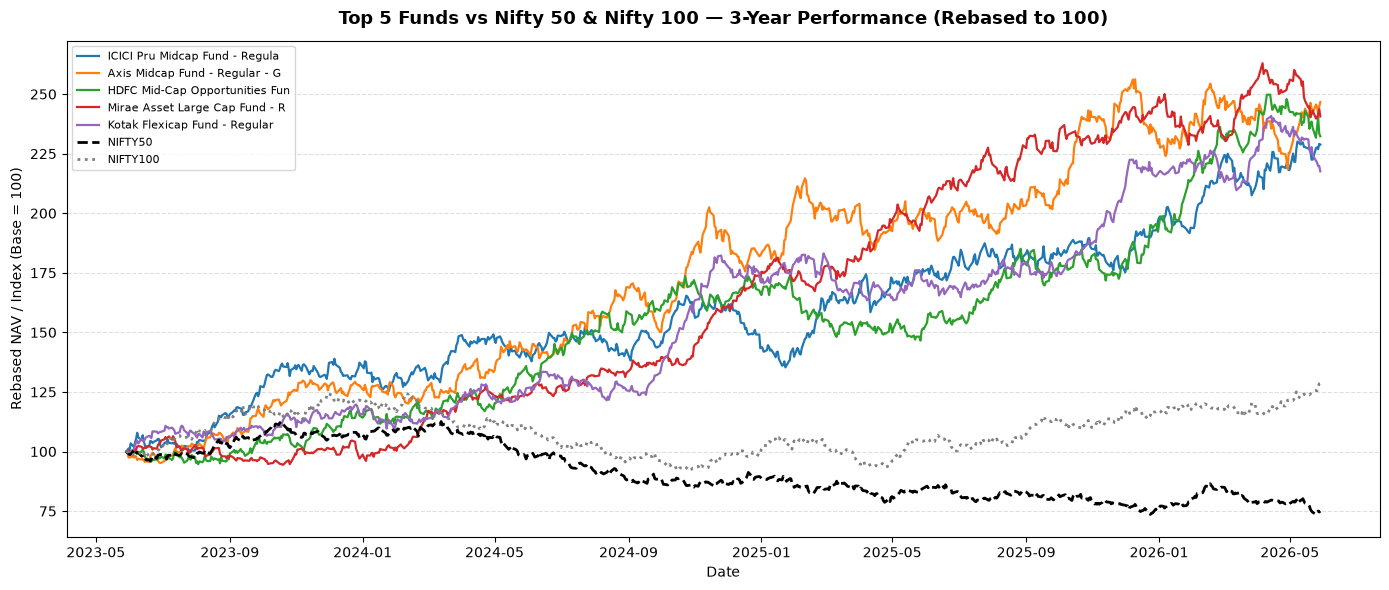

Chart saved → reports/benchmark_chart.png


In [12]:
# Task 8: Top 5 funds vs Nifty 50 & Nifty 100 (3-year, rebased to 100)
top5_codes = score_df["amfi_code"].head(5).tolist()
cutoff = asof - pd.DateOffset(years=3)

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10.colors

# Fund lines
for i, code in enumerate(top5_codes):
    g = nav[(nav["amfi_code"]==code) & (nav["date"]>=cutoff)].sort_values("date")
    rebased = g["nav"] / g["nav"].iloc[0] * 100
    name = fm.loc[fm["amfi_code"]==code, "scheme_name"].values[0][:30]
    ax.plot(g["date"], rebased, label=name, color=colors[i], linewidth=1.6)

# Benchmark lines
for idx_name, style, lw in [("NIFTY50","--",2), ("NIFTY100",":",2)]:
    b = bench[(bench["index_name"]==idx_name) & (bench["date"]>=cutoff)].sort_values("date")
    rebased_b = b["close_value"] / b["close_value"].iloc[0] * 100
    ax.plot(b["date"], rebased_b, label=idx_name, linestyle=style,
            color="black" if idx_name=="NIFTY50" else "grey", linewidth=lw)

ax.set_title("Top 5 Funds vs Nifty 50 & Nifty 100 — 3-Year Performance (Rebased to 100)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Date");  ax.set_ylabel("Rebased NAV / Index (Base = 100)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "reports", "benchmark_chart.png"), dpi=150)
plt.show()
print("Chart saved → reports/benchmark_chart.png")

In [13]:
# Tracking error vs NIFTY100 for top 5 funds
nifty100_ret = (bench[bench["index_name"]=="NIFTY100"]
                .sort_values("date").set_index("date")["close_value"].pct_change())

te_rows = []
for code in top5_codes:
    g = nav[nav["amfi_code"]==code].sort_values("date").set_index("date")
    merged = g["daily_return"].to_frame().join(nifty100_ret.rename("mkt"), how="inner").dropna()
    active_ret = merged["daily_return"] - merged["mkt"]
    te = active_ret.std() * np.sqrt(TD) * 100
    ir = active_ret.mean() / active_ret.std() * np.sqrt(TD)
    name = fm.loc[fm["amfi_code"]==code, "scheme_name"].values[0][:40]
    te_rows.append({"scheme_name": name, "tracking_error_pct": round(te,2),
                    "information_ratio": round(ir,4)})

te_df = pd.DataFrame(te_rows)
print("Tracking Error vs NIFTY100:")
print(te_df.to_string(index=False))


Tracking Error vs NIFTY100:
                             scheme_name  tracking_error_pct  information_ratio
ICICI Pru Midcap Fund - Regular - Growth               23.20             1.1290
     Axis Midcap Fund - Regular - Growth               23.77             0.9592
HDFC Mid-Cap Opportunities Fund - Regula               22.87             1.0553
Mirae Asset Large Cap Fund - Regular - G               18.97             1.2643
  Kotak Flexicap Fund - Regular - Growth               20.64             1.1715
